<a href="https://colab.research.google.com/github/JorgeRojas720s/AI_Agents/blob/main/Laboratorio_S03_BDS_DFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EIF420O – Inteligencia Artificial | Semana 3
## Universidad Nacional · Sede Regional Brunca – Campus Coto



---



## Configuración Inicial

En este punto se agregan las librerías necesarias y se crea la clase Nodo, importante para todo el laboratorio.

In [108]:
#Librerias
import collections
import heapq # Cola con prioridad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Se utiliza para dibujar formas geométricas
import networkx as nx # Se utiliza para modelar y analizar estructuras de grafos como redes sociales, rutas, mapas, dependencias o algoritmos de búsqueda, etc.
import numpy as np

#  Clase generica para los nodos de los ejercicios
class Nodo:

    def __init__(self, estado, padre=None, accion=None, costo=0):
        self.estado = estado
        self.padre  = padre
        self.accion = accion
        self.costo  = costo

    # Este metodo es necesario para el heapq (cola de prioridad)
    def __lt__(self, otro):
        return self.costo < otro.costo

def reconstruir_camino(nodo):
    camino, acciones = [], []
    while nodo:
        camino.append(nodo.estado)
        if nodo.accion:
            acciones.append(nodo.accion)
        nodo = nodo.padre
    camino.reverse(); acciones.reverse()
    return camino, acciones

# Ejemplo 1 - Red de autobuses: San José → Ciudad Neily

## Situación real:

Un estudiante que regresa a Ciudad Neily despues de realizar un trámite en San José necesita encontrar la ruta con menor número de transbordos (no el menor tiempo, sino menos cambios de bus - supongamos que se requiere el transbordo)

Selección BFS o DFS: Para este caso el BFS garantiza el camnino con menor cantidad de salto, que en este caos es equivalente a la profundidad minima en el árbol.

Formulación del problema:
Estado: Cuidad donde se encuentra actualmente el estudiante.

*   Estado inicial: San José
* Meta: Cuidad Neily (Entrada Campus Coto)
* Acciones: Tomar un bus directo entre dos ciudades conectadas
* Costo de camino: Número de transbordos realizados (cada bus = 1 transbordo)

Grafo de las rutas de autobus - grafo no dirigido

Cada par rrepsenta una ruta directa entre dos cuidades.

In [109]:
RUTAS_BUS = {
    'San José':        ['Cartago', 'Alajuela', 'San Isidro PZ', 'Liberia', 'Puntarenas'],
    'Cartago':         ['San José', 'Turrialba', 'San Isidro PZ'],
    'Alajuela':        ['San José', 'Ciudad Quesada', 'Liberia'],
    'Ciudad Quesada':  ['Alajuela', 'Liberia', 'Upala'],
    'Liberia':         ['San José', 'Alajuela', 'Ciudad Quesada', 'Nicoya', 'La Cruz'],
    'Puntarenas':      ['San José', 'Nicoya', 'Quepos'],
    'Nicoya':          ['Liberia', 'Puntarenas'],
    'Turrialba':       ['Cartago', 'Siquirres'],
    'Siquirres':       ['Turrialba', 'Limón', 'Guápiles'],
    'Limón':           ['Siquirres', 'Bribrí'],
    'Bribrí':          ['Limón'],
    'Guápiles':        ['Siquirres', 'Ciudad Quesada'],
    'Quepos':          ['Puntarenas', 'San Isidro PZ'],
    'San Isidro PZ':   ['San José', 'Cartago', 'Quepos', 'Buenos Aires', 'Dominical'],
    'Buenos Aires':    ['San Isidro PZ', 'Palmar Norte'],
    'Palmar Norte':    ['Buenos Aires', 'Ciudad Neily', 'Sierpe'],
    'Sierpe':          ['Palmar Norte'],
    'Ciudad Neily':    ['Palmar Norte', 'Paso Canoas', 'San Vito'],
    'San Vito':        ['Ciudad Neily'],
    'Paso Canoas':     ['Ciudad Neily'],
    'Dominical':       ['San Isidro PZ', 'Palmar Norte'],
    'La Cruz':         ['Liberia'],
    'Upala':           ['Ciudad Quesada'],
}


def bfs_transbordos(grafo, inicio, meta):
    """
    BFS sobre grafo de ciudades.
    Busca reducir el numero de transbordos
    """
    frontera  = collections.deque([Nodo(inicio)])
    visitados = {inicio}
    expansiones = 0

    while frontera:
        nodo = frontera.popleft()
        expansiones += 1

        if nodo.estado == meta:
            return reconstruir_camino(nodo), expansiones

        for ciudad_vecina in grafo.get(nodo.estado, []):
            if ciudad_vecina not in visitados:
                visitados.add(ciudad_vecina)
                hijo = Nodo(
                    estado = ciudad_vecina,
                    padre  = nodo,
                    accion = f'Bus {nodo.estado} → {ciudad_vecina}',
                    costo  = nodo.costo + 1
                )
                frontera.append(hijo)

    return (None, None), expansiones

# Ejecutar el proceso

INICIO = 'San José'
META   = 'Ciudad Neily'

(camino, acciones), expansiones = bfs_transbordos(RUTAS_BUS, INICIO, META)

print('-' * 60)
print('  BFS – Ruta con menor numero de transbordos')
print('  San José -> Ciudad Neily ')
print('-' * 60)
print(f'\nRuta encontrada ({len(camino)-1} transbordos):')
for i, ciudad in enumerate(camino):
    prefijo = '  Inicio →' if i == 0 else (f'  [{i}]     ' if i < len(camino)-1 else '  META  ->')
    print(f'{prefijo} {ciudad}')
print(f'\nNodos explorados: {expansiones}')
print('\nSecuencia de buses:')
for a in acciones:
    print(f' {a}')

------------------------------------------------------------
  BFS – Ruta con menor numero de transbordos
  San José -> Ciudad Neily 
------------------------------------------------------------

Ruta encontrada (4 transbordos):
  Inicio → San José
  [1]      San Isidro PZ
  [2]      Buenos Aires
  [3]      Palmar Norte
  META  -> Ciudad Neily

Nodos explorados: 19

Secuencia de buses:
 Bus San José → San Isidro PZ
 Bus San Isidro PZ → Buenos Aires
 Bus Buenos Aires → Palmar Norte
 Bus Palmar Norte → Ciudad Neily


Grafico de visualización del grafo

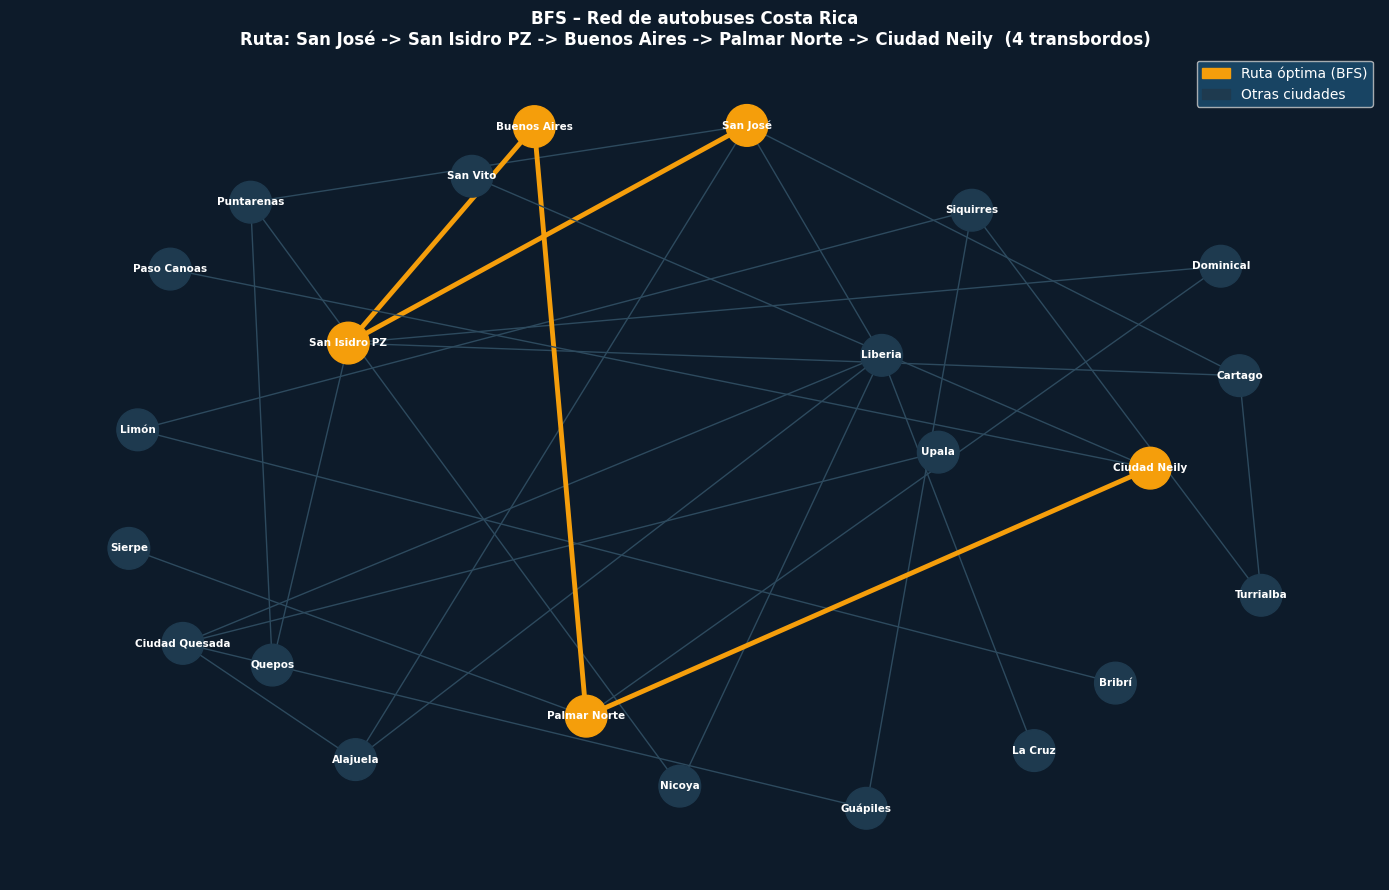

In [110]:
G = nx.Graph()
for ciudad, conexiones in RUTAS_BUS.items():
    for c in conexiones:
        G.add_edge(ciudad, c)

# Colores: ruta encontrada en naranja, resto en gris
nodos_ruta = set(camino)
aristas_ruta = set(zip(camino, camino[1:]))

node_colors = ['#F59E0B' if n in nodos_ruta else '#1E3A4F' for n in G.nodes()]
edge_colors = ['#F59E0B' if (u,v) in aristas_ruta or (v,u) in aristas_ruta
                else '#2D4A5E' for u, v in G.edges()]
edge_widths = [3.5 if (u,v) in aristas_ruta or (v,u) in aristas_ruta
               else 1.0 for u, v in G.edges()]

pos = nx.spring_layout(G, seed=42, k=2.2)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#0D1B2A')
fig.patch.set_facecolor('#0D1B2A')

nx.draw_networkx(
    G, pos, ax=ax,
    node_color=node_colors,
    edge_color=edge_colors,
    width=edge_widths,
    node_size=900,
    font_size=7.5,
    font_color='white',
    font_weight='bold'
)

plt.title(
    f'BFS – Red de autobuses Costa Rica\n'
    f'Ruta: {" -> ".join(camino)}  ({len(camino)-1} transbordos)',
    color='white', fontsize=12, fontweight='bold'
)
leyenda = [
    mpatches.Patch(color='#F59E0B', label='Ruta óptima (BFS)'),
    mpatches.Patch(color='#1E3A4F', label='Otras ciudades'),
]
ax.legend(handles=leyenda, facecolor='#1B4F72', labelcolor='white', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

# Ejercicio evaluado Grados de separación en una red de contactos


Situación real:


La teoría de los seis grados de separación dice que cualquier persona en el mundo está conectada a cualquier otra persona a través de a lo sumo 6 contactos; esta misma lógica se usa para:



*   Rastrear cómo se propaga un rumor o virus en WhatsApp.

*   Encontrar el camino más corto entre dos perfiles de LinkedIn.

* Sistemas de recomendación de amigos


Utilice un BFS para encontrar el camino con el menor número de intermediarios entre dos personas:


Formulación:



* Estado: Persona actual en la red

* Estado inicial: Persona A

* Meta: Persona B

* Acciones: Conectar a través de un contacto en común.

* Costo: Número de intermediarios



Resuélvelo: Elabore el código y la gráfica y explique paso a paso en el documento de Colab.

In [111]:
# Código Aquí


RED_CONTACTOS = {
    "Ana": ["Luis", "Carlos", "Sofía"],
    "Luis": ["Ana", "Pedro"],
    "Carlos": ["Ana", "María"],
    "Sofía": ["Ana", "Pedro", "Lucía"],
    "Pedro": ["Luis", "Sofía", "Jorge"],
    "María": ["Carlos", "Lucía"],
    "Lucía": ["Sofía", "María", "Jorge"],
    "Jorge": ["Pedro", "Lucía"]
}

def bfs_contactos(grafo, inicio, meta):
  frontera = collections.deque([Nodo(inicio)])
  visitados = {inicio}
  expansiones = 0

  while frontera:
    nodo = frontera.popleft()
    print(nodo.estado)
    expansiones += 1

    if nodo.estado == meta:
      return reconstruir_camino(nodo), expansiones

    for contacto in grafo.get(nodo.estado, []):
      if contacto not in visitados:
        visitados.add(contacto)
        hijo = Nodo(
            estado = contacto,
            padre = nodo,
            accion = f'Conexión {nodo.estado} --> {contacto}',
            costo = nodo.costo + 1
        )
        frontera.append(hijo)

  return (None, None), expansiones

INICIO = "Ana"
META = "Jorge"

(camino, acciones), expansiones = bfs_contactos(RED_CONTACTOS, INICIO, META)

print("-" * 50)
print("BFS – Grados de separación en una red de contactos")
print("-" * 50)

print(f"\nCamino encontrado ({len(camino)-1} intermediarios):")

for i, persona in enumerate(camino):
    prefijo = "Inicio →" if i == 0 else (
        f"[{i}]     " if i < len(camino)-1 else "META  ->"
    )
    print(f"{prefijo} {persona}")

print("\nConexiones:")
for a in acciones:
    print(a)

print(f"\nNodos explorados: {expansiones}")



Ana
Luis
Carlos
Sofía
Pedro
María
Lucía
Jorge
--------------------------------------------------
BFS – Grados de separación en una red de contactos
--------------------------------------------------

Camino encontrado (3 intermediarios):
Inicio → Ana
[1]      Luis
[2]      Pedro
META  -> Jorge

Conexiones:
Conexión Ana --> Luis
Conexión Luis --> Pedro
Conexión Pedro --> Jorge

Nodos explorados: 8


## Visulalización

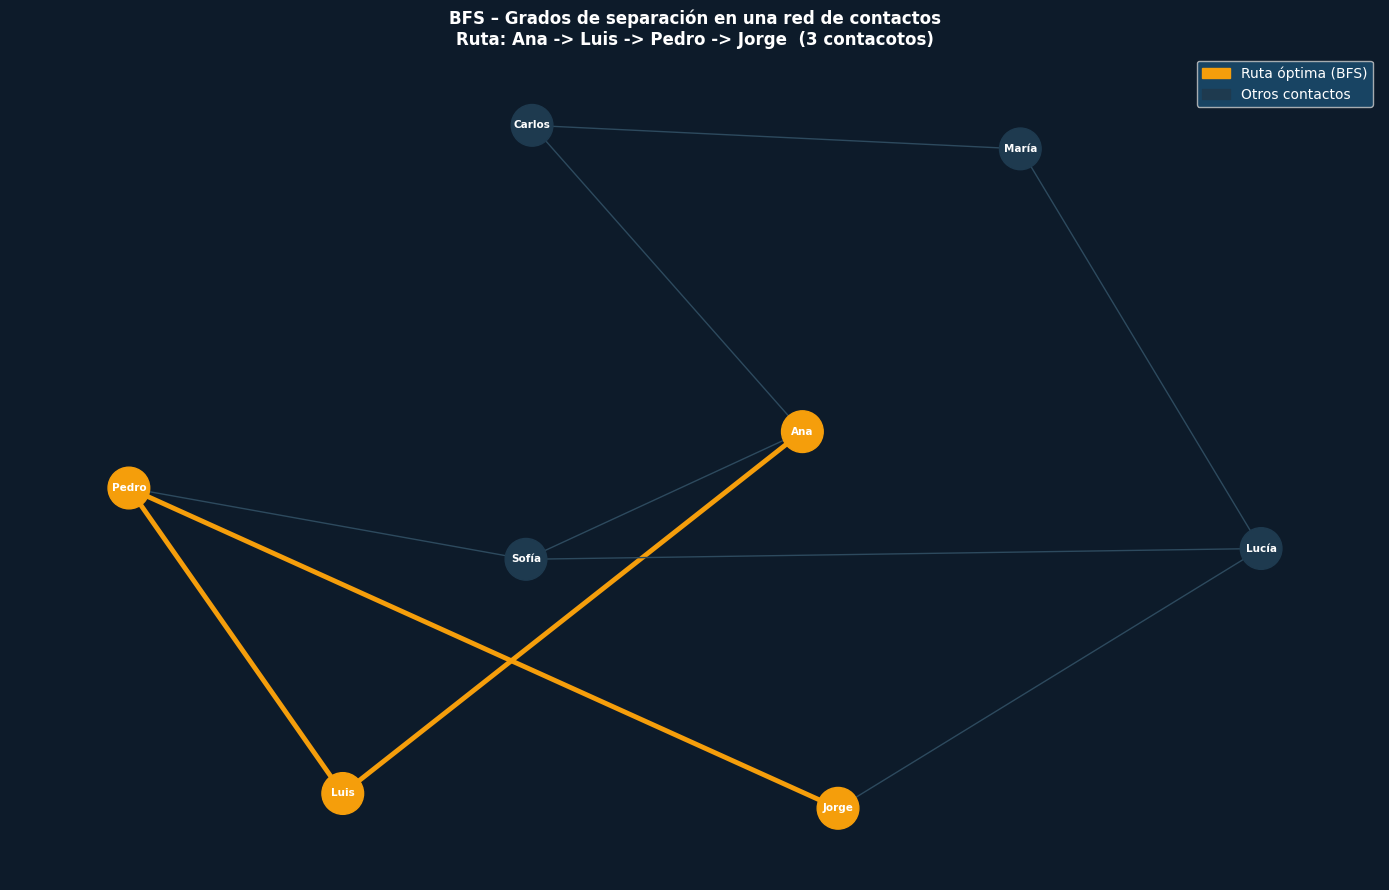

In [112]:
G = nx.Graph()
for contacto, conexiones in RED_CONTACTOS.items():
    for c in conexiones:
        G.add_edge(contacto, c)

# Colores: ruta encontrada en naranja, resto en gris
nodos_ruta = set(camino)
aristas_ruta = set(zip(camino, camino[1:]))

node_colors = ['#F59E0B' if n in nodos_ruta else '#1E3A4F' for n in G.nodes()]
edge_colors = ['#F59E0B' if (u,v) in aristas_ruta or (v,u) in aristas_ruta
                else '#2D4A5E' for u, v in G.edges()]
edge_widths = [3.5 if (u,v) in aristas_ruta or (v,u) in aristas_ruta
               else 1.0 for u, v in G.edges()]

pos = nx.spring_layout(G, seed=45, k=2.2)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#0D1B2A')
fig.patch.set_facecolor('#0D1B2A')

nx.draw_networkx(
    G, pos, ax=ax,
    node_color=node_colors,
    edge_color=edge_colors,
    width=edge_widths,
    node_size=900,
    font_size=7.5,
    font_color='white',
    font_weight='bold'
)

plt.title(
    f'BFS – Grados de separación en una red de contactos\n'
    f'Ruta: {" -> ".join(camino)}  ({len(camino)-1} contacotos)',
    color='white', fontsize=12, fontweight='bold'
)
leyenda = [
    mpatches.Patch(color='#F59E0B', label='Ruta óptima (BFS)'),
    mpatches.Patch(color='#1E3A4F', label='Otros contactos'),
]
ax.legend(handles=leyenda, facecolor='#1B4F72', labelcolor='white', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

## Rúbrica de evaluación

<table>
<thead>
<tr>
<th style="width:5%">#</th>
<th style="width:20%">Criterio</th>
<th style="width:50%">Indicadores de desempeño</th>
<th style="width:10%">Pts.</th>
<th style="width:15%">Calificación</th>
</tr>
</thead>
<tbody>
<tr>
<td>1</td>
<td>Formulación del problema</td>
<td style="max-width:200px">
Identifica correctamente los 5 componentes: Estado, Estado inicial, Meta, Acciones y Costo.
Justifica por qué BFS es adecuado para este problema.
</td>
<td>20</td>
<td></td>
</tr>

<tr>
<td>2</td>
<td>Implementación del algoritmo BFS</td>
<td style="max-width:200px">
El código implementa BFS desde cero (sin usar nx.shortest_path).
Usa cola FIFO (deque) correctamente.
Registra predecesores y reconstruye el camino óptimo.
Maneja correctamente el caso en que no hay conexión.
</td>
<td>30</td>
<td></td>
</tr>

<tr>
<td>3</td>
<td>Construcción y modelado de la red</td>
<td style="max-width:200px">
El grafo es no dirigido y representa relaciones bidireccionales.
Cuenta con al menos 8 nodos y 10 conexiones.
La red es conexa (todos los nodos son alcanzables).
</td>
<td>15</td>
<td></td>
</tr>

<tr>
<td>4</td>
<td>Visualización del grafo</td>
<td style="max-width:200px">
Grafica el grafo completo con etiquetas de nombres.
Destaca visualmente el camino óptimo encontrado.
Diferencia origen, destino e intermediarios por color.
Incluye leyenda explicativa.
</td>
<td>20</td>
<td></td>
</tr>

<tr>
<td>5</td>
<td>Explicación y documentación en Colab</td>
<td style="max-width:200px">
Celdas de texto explican cada paso antes del código.
Interpreta el resultado: número de grados e intermediarios.
Relaciona la solución con la teoría de los seis grados.
Redacción clara y sin errores conceptuales.
</td>
<td>15</td>
<td></td>
</tr>

<tr>
<td></td>
<td><strong>TOTAL</strong></td>
<td></td>
<td><strong>/ 100</strong></td>
<td></td>
</tr>

</tbody>
</table>|

## Ejemplo 2 — Ruta de reparto de Correos de Costa Rica (costos variables)

**Situación real:**  
Correos de CR necesita enviar un paquete desde la oficina central en **San Isidro de El General**
hasta una dirección en **San Vito de Coto Brus**. Existen varias rutas posibles, pero cada una
tiene un **costo en kilómetros diferente**.

En este caso, BFS no funciona porque los costos no son uniformes (no todos los tramos
tienen la misma distancia). Se necesita **Búsqueda de Costo Uniforme (UCS)**.

**Formulación:**
- **Estado:** Punto de distribución actual
- **Estado inicial:** San Isidro de El General
- **Meta:** San Vito de Coto Brus
- **Acciones:** Conducir de un punto al siguiente
- **Costo de camino:** Kilómetros recorridos (variable por tramo)

In [113]:
# Grafo ponderado y no dirigido: ciudad -> [(ciudad_vecina, km)]
# Distancias aproximadas en kilómetros por carretera
MAPA_CORREOS = {
    'San Isidro PZ':  [('Buenos Aires', 62), ('Dominical', 44), ('Quepos', 72)],
    'Buenos Aires':   [('San Isidro PZ', 62), ('Palmar Norte', 55), ('Boruca', 30)],
    'Boruca':         [('Buenos Aires', 30), ('Palmar Norte', 35)],
    'Dominical':      [('San Isidro PZ', 44), ('Palmar Norte', 50), ('Uvita', 18)],
    'Uvita':          [('Dominical', 18), ('Palmar Norte', 32)],
    'Quepos':         [('San Isidro PZ', 72), ('Dominical', 54)],
    'Palmar Norte':   [('Buenos Aires', 55), ('Boruca', 35), ('Dominical', 50),
                       ('Uvita', 32), ('Ciudad Neily', 48), ('Sierpe', 14)],
    'Sierpe':         [('Palmar Norte', 14)],
    'Ciudad Neily':   [('Palmar Norte', 48), ('Paso Canoas', 18), ('San Vito', 38)],
    'Paso Canoas':    [('Ciudad Neily', 18)],
    'San Vito':       [('Ciudad Neily', 38)],
}


def ucs(grafo, inicio, meta):
    """
    Búsqueda de Costo Uniforme (Uniform Cost Search).
    Usa una cola de prioridad (min-heap) para expandir
    siempre el nodo con menor costo acumulado.
    """
    # Cola de prioridad: (costo_acumulado, nodo)
    cola_prioridad = [(0, Nodo(inicio))]
    visitados  = {}   # estado -> menor costo encontrado
    expansiones = 0

    print(f'UCS – Ruta mínima en km: {inicio} → {meta}')
    print('-' * 55)

    while cola_prioridad:
        costo_actual, nodo = heapq.heappop(cola_prioridad)
        expansiones += 1

        print(f'  Expandiendo: {nodo.estado:<20} costo acumulado: {costo_actual} km')

        # Si ya visitamos con menor costo, ignorar
        if nodo.estado in visitados:
            continue
        visitados[nodo.estado] = costo_actual

        if nodo.estado == meta:
            camino, acciones = reconstruir_camino(nodo)
            print(f'\n RUTA ÓPTIMA ENCONTRADA')
            print(f'  Distancia total: {costo_actual} km')
            return camino, acciones, costo_actual, expansiones

        for (vecino, km) in grafo.get(nodo.estado, []):
            if vecino not in visitados:
                nuevo_costo = costo_actual + km
                hijo = Nodo(
                    estado = vecino,
                    padre  = nodo,
                    accion = f'{nodo.estado} -> {vecino} ({km} km)',
                    costo  = nuevo_costo
                )
                heapq.heappush(cola_prioridad, (nuevo_costo, hijo))

    return None, None, -1, expansiones

# Ejecutar UCS

camino_ucs, acciones_ucs, dist_total, exp_ucs = ucs(
    MAPA_CORREOS, 'San Isidro PZ', 'San Vito'
)

print(f'\nRuta: {" -> ".join(camino_ucs)}')
print(f'\nDetalle del recorrido:')
for a in acciones_ucs:
    print(f' Bus {a}')
print(f'\nDistancia total óptima: {dist_total} km')

# ── Comparar con ruta NO óptima ───────────────────────────────
ruta_obvia = ['San Isidro PZ', 'Buenos Aires', 'Palmar Norte', 'Ciudad Neily', 'San Vito']
km_ruta_obvia = 62 + 55 + 48 + 38
print(f'\nComparación con ruta "obvia":')
print(f'  Ruta obvia   : {" -> ".join(ruta_obvia)} = {km_ruta_obvia} km')
print(f'  Ruta UCS     : {" -> ".join(camino_ucs)} = {dist_total} km')
print(f'  Ahorro       : {km_ruta_obvia - dist_total} km ({((km_ruta_obvia-dist_total)/km_ruta_obvia*100):.1f}%)')

UCS – Ruta mínima en km: San Isidro PZ → San Vito
-------------------------------------------------------
  Expandiendo: San Isidro PZ        costo acumulado: 0 km
  Expandiendo: Dominical            costo acumulado: 44 km
  Expandiendo: Buenos Aires         costo acumulado: 62 km
  Expandiendo: Uvita                costo acumulado: 62 km
  Expandiendo: Quepos               costo acumulado: 72 km
  Expandiendo: Boruca               costo acumulado: 92 km
  Expandiendo: Palmar Norte         costo acumulado: 94 km
  Expandiendo: Palmar Norte         costo acumulado: 94 km
  Expandiendo: Sierpe               costo acumulado: 108 km
  Expandiendo: Palmar Norte         costo acumulado: 117 km
  Expandiendo: Palmar Norte         costo acumulado: 127 km
  Expandiendo: Ciudad Neily         costo acumulado: 142 km
  Expandiendo: Paso Canoas          costo acumulado: 160 km
  Expandiendo: San Vito             costo acumulado: 180 km

 RUTA ÓPTIMA ENCONTRADA
  Distancia total: 180 km

Ruta: San I



---
## Ejercicio 2 - Exploración de cuevas en Minecraft

**Situación real:**  
En Minecraft, cuando un jugador entra a una cueva, el juego necesita determinar qué tan
grande es la cueva (cuántos bloques de aire están conectados). Para esto usa el mismo
principio de DFS: entra tan profundo como sea posible antes de retroceder.

La misma lógica se usa en:
- **Fill de Paint / Photoshop** ("balde de pintura"): DFS desde el pixel inicial
- **Detección de islas** en mapas: cada masa de tierra conectada es una isla
- **Análisis de componentes conectados** en grafos

**Problema específico:**  
Dado un mapa de una cueva (cuadrícula de bloques), calcular el **tamaño total de la caverna**
(cuántos espacios abiertos están conectados desde la entrada).

**Formulación:**
- **Estado:** Bloque actual (fila, columna)
- **Estado inicial:** Entrada de la cueva
- **Meta:** No hay meta fija – explorar todo el espacio accesible
- **Acciones:** Moverse a bloque adyacente si está vacío (no es roca)


In [114]:
# Código aquí

# R = roca
# A = aire
# E = entrada

MAPA_CUEVA = [
['R','R','R','R','R','R','R','R','R','R'],
['R','E','A','A','R','A','A','A','A','R'],
['R','A','R','A','R','A','R','R','A','R'],
['R','A','R','A','A','A','A','R','A','R'],
['R','A','R','R','R','R','A','R','A','R'],
['R','A','A','A','A','R','A','A','A','R'],
['R','R','R','R','A','R','R','R','A','R'],
['R','A','A','R','A','A','A','R','A','R'],
['R','A','R','R','R','R','A','A','A','R'],
['R','R','R','R','R','R','R','R','R','R']
]


def dfs_cueva(mapa, inicio):

    pila = [Nodo(inicio)]   # stack
    visitados = set()
    bloques = 0
    expansiones = 0

    filas = len(mapa)
    columnas = len(mapa[0])

    print("DFS – Exploración de cueva")
    print("-"*40)

    while pila:

        nodo = pila.pop()
        fila, col = nodo.estado

        if nodo.estado in visitados:
            continue

        visitados.add(nodo.estado)
        expansiones += 1
        bloques += 1

        if mapa[fila][col] != 'E':
          mapa[fila][col] = 'X'

        print(f"Explorando bloque {nodo.estado}")

        # movimientos posibles
        movimientos = [
            (fila+1, col),
            (fila-1, col),
            (fila, col+1),
            (fila, col-1)
        ]

        for f, c in movimientos:

            if 0 <= f < filas and 0 <= c < columnas:

                if mapa[f][c] != 'R' and (f,c) not in visitados:

                    hijo = Nodo(
                        estado=(f,c),
                        padre=nodo,
                        accion=f"{nodo.estado} -> {(f,c)}"
                    )

                    pila.append(hijo)

    return bloques, expansiones


# buscar entrada
for i in range(len(MAPA_CUEVA)):
    for j in range(len(MAPA_CUEVA[0])):
        if MAPA_CUEVA[i][j] == 'E':
            entrada = (i,j)

bloques, expansiones = dfs_cueva(MAPA_CUEVA, entrada)

print("\nTamaño de la cueva:", bloques)
print("Bloques explorados:", expansiones)

DFS – Exploración de cueva
----------------------------------------
Explorando bloque (1, 1)
Explorando bloque (1, 2)
Explorando bloque (1, 3)
Explorando bloque (2, 3)
Explorando bloque (3, 3)
Explorando bloque (3, 4)
Explorando bloque (3, 5)
Explorando bloque (3, 6)
Explorando bloque (4, 6)
Explorando bloque (5, 6)
Explorando bloque (5, 7)
Explorando bloque (5, 8)
Explorando bloque (4, 8)
Explorando bloque (3, 8)
Explorando bloque (2, 8)
Explorando bloque (1, 8)
Explorando bloque (1, 7)
Explorando bloque (1, 6)
Explorando bloque (1, 5)
Explorando bloque (2, 5)
Explorando bloque (6, 8)
Explorando bloque (7, 8)
Explorando bloque (8, 8)
Explorando bloque (8, 7)
Explorando bloque (8, 6)
Explorando bloque (7, 6)
Explorando bloque (7, 5)
Explorando bloque (7, 4)
Explorando bloque (6, 4)
Explorando bloque (5, 4)
Explorando bloque (5, 3)
Explorando bloque (5, 2)
Explorando bloque (5, 1)
Explorando bloque (4, 1)
Explorando bloque (3, 1)
Explorando bloque (2, 1)

Tamaño de la cueva: 36
Bloques 

## Visualización de la cueva explorada

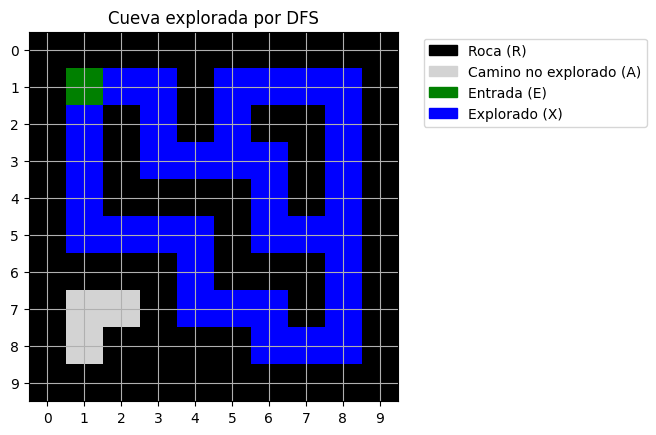

In [115]:
# Código aquí

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def visualizar_cueva(mapa):

    colores = {
        'R': 0,  # roca
        'A': 1,  # aire no explorado
        'E': 2,  # entrada
        'X': 3   # aire explorado
    }

    matriz = np.array([[colores[c] for c in fila] for fila in mapa])

    cmap = ListedColormap([
        "black",      # R
        "lightgray",  # A
        "green",      # E
        "blue"        # X
    ])

    plt.imshow(matriz, cmap=cmap)

    plt.title("Cueva explorada por DFS")
    plt.xticks(range(len(mapa[0])))
    plt.yticks(range(len(mapa)))
    plt.grid(True)

    leyenda = [
        mpatches.Patch(color='black', label='Roca (R)'),
        mpatches.Patch(color='lightgray', label='Camino no explorado (A)'),
        mpatches.Patch(color='green', label='Entrada (E)'),
        mpatches.Patch(color='blue', label='Explorado (X)')
    ]

    plt.legend(handles=leyenda, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

visualizar_cueva(MAPA_CUEVA)